# **Deep Learning Project**
# ***Predicting if a bank customer will exit the bank***

### Importing the libraries

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

### Importing the dataset

In [ ]:
dataset = pd.read_csv("./../../../data/raw/Bank_Customers.csv")
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

In [ ]:
#print(X)
#print(y)

## **Data preprocessing**

### Splitting the data into train & test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Replace missing data

In [ ]:
from sklearn.impute import SimpleImputer

numerical_columns = [0, 3, 4, 5, 6, 9]
categorical_columns = [1, 2, 7, 8]

imputer = SimpleImputer(missing_values=np.nan, strategy="median")
imputer.fit(X_train[:, numerical_columns])
X_train[:, numerical_columns] = imputer.transform(X_train[:, numerical_columns])
X_test[:, numerical_columns] = imputer.transform(X_test[:, numerical_columns])

imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
imputer.fit(X_train[:, categorical_columns])
X_train[:, categorical_columns] = imputer.transform(X_train[:, categorical_columns])
X_test[:, categorical_columns] = imputer.transform(X_test[:, categorical_columns])


### One-hot encoding the geography  & gender column

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(sparse_output=False), [1, 2])],
    remainder="passthrough",
)
X_train = np.array(ct.fit_transform(X_train))
X_test = np.array(ct.transform(X_test))

### Feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## **Building the Nerual Network**

A feedforward neural network is constructed with:

*   Two hidden layers (both 6 neurons) using ReLU activation function.
*   One output layer with Sigmoid activation function for binary classification.

ReLU is used to introduce non-linearity, while Sigmoid outputs probabilities between 0 and 1.

### Initializing the ANN

In [ ]:
model = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

In [ ]:
model.add(tf.keras.layers.Dense(6, activation="relu", input_shape=(X_train.shape[1],)))

### Adding the second hidden layer

In [ ]:
model.add(tf.keras.layers.Dense(6, activation="relu"))

### Adding the output layer

In [ ]:
model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

## **Training the ANN**


### Compiling the ANN
The model is compiled using:


*   **Adam optimizer** with learning rate 0.001 for efficient gradient updates.
*   **Binary Crossentropy loss**, suitable for binary classification tasks.
*   Evaluation metrics including Accuracy, Precision, Recall, and AUC to comprehensively assess performance.








In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

### Callbacks - Saving checkpoint
**ModelCheckpoint** saves the best-performing model during training.
These techniques improve model generalization and reproducibility.

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
)

### Training the ANN on the Training set

The model is trained for up to 100 epochs with a batch size of 32.
A validation split is used to monitor generalization performance during training.

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7527 - auc: 0.5486 - loss: 0.5694 - precision: 0.1972 - recall: 0.0643 - val_accuracy: 0.7987 - val_auc: 0.6022 - val_loss: 0.5100 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - auc: 0.6474 - loss: 0.4912 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7987 - val_auc: 0.6749 - val_loss: 0.4751 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - auc: 0.7013 - loss: 0.4686 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7987 - val_auc: 0.7138 - val_loss: 0.4570 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - auc: 0.7311 - loss: 0.4555 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7987 - val_auc: 0.7383 - val_loss: 0.4453 - val_precision: 0.0000e+

### Performance Visualization - Training and Validation Curves

Loss and performance metrics are plotted over epochs.
These curves help diagnose:

*   Underfitting
*   Overfitting
*   Training stability

Visualization allows better understanding of model learning behavior.

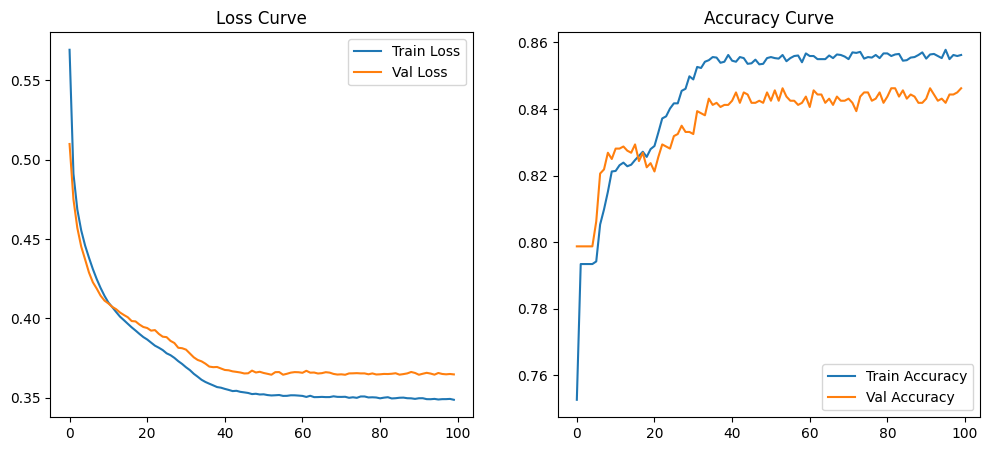

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

#### `Training Dynamics and Overfitting Analysis`

The training loss continuously decreases, while the validation loss stabilizes after an initial improvement. 
A small but consistent gap between training and validation curves indicates mild overfitting.

-> Issue :

The model continues improving on training data but stops improving on validation data.

-> Improvement Strategy :
- Introducing **Dropout** layers to reduce co-adaptation.
- Applying **L2 regularization** to penalize large weights.
- Using **EarlyStopping** to prevent unnecessary training beyond convergence.
